In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid
from facenet_pytorch import MTCNN

from tqdm import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [2]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
LR = 2e-4
BETAS = (0.5, 0.999)
IMAGE_SIZE = 64

IMG_DIR = 'celeba/img_align_celeba'
ATTR_CSV = 'celeba/list_attr_celeba.csv'
PART_CSV = 'celeba/list_eval_partition.csv'
CROP_DIR = 'celeba/mtcnn_faces_64'
os.makedirs(CROP_DIR, exist_ok=True)

In [4]:
attrs = pd.read_csv(ATTR_CSV, usecols=['image_id', 'Male'])
parts = pd.read_csv(PART_CSV, usecols=['image_id', 'partition'])

df = parts.merge(attrs, on='image_id')
df['gender'] = (df['Male'] == 1).astype(int)

print('Размер датасета ', len(df))
print(df.head())

Размер датасета  202599
     image_id  partition  Male  gender
0  000001.jpg          0    -1       0
1  000002.jpg          0    -1       0
2  000003.jpg          0     1       1
3  000004.jpg          0    -1       0
4  000005.jpg          0    -1       0


In [5]:
def crop_with_detector(img, boxes, probs, scale=1.2):
    if boxes is None or len(boxes) == 0 or probs is None:
        return None
    
    best = int(np.argmax(probs))
    x1, y1, x2, y2 = boxes[best]
    
    W, H = img.size
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    side = max(x2 - x1, y2 - y1) * scale
    
    left = int(round(cx - side / 2))
    top = int(round(cy - side / 2))
    right = int(round(cx + side / 2))
    bottom = int(round(cy + side / 2))
    
    left = max(0, left)
    top = max(0, top)
    right = min(W, right)
    bottom = min(H, bottom)
    
    if right <= left or bottom <= top:
        return None
    
    return img.crop((left, top, right, bottom))

In [6]:
def preprocess_faces_mtcnn(dataframe, img_dir, save_dir, image_size=64):
    os.makedirs(save_dir, exist_ok=True)
    mtcnn = MTCNN(keep_all=False, device=device)
    
    kept_rows = []
    dropped = 0
    
    for row in tqdm(dataframe.itertuples(index=False), total=len(dataframe), desc='детекция лиц'):
        src = os.path.join(img_dir, row.image_id)
        dst = os.path.join(save_dir, row.image_id)
        
        try:
            img = Image.open(src).convert('RGB')
            boxes, probs = mtcnn.detect(img)
            face = crop_with_detector(img, boxes, probs, scale=1.2)
            
            if face is None:
                dropped += 1
                continue
            
            face = face.resize((image_size, image_size))
            face.save(dst)
            kept_rows.append(row._asdict())
        
        except Exception:
            dropped += 1
            continue
    
    print(f"Сохранено: {len(kept_rows)}")
    print(f"Откинуто: {dropped}")
    return pd.DataFrame(kept_rows).reset_index(drop=True)

In [7]:
# proc_df = preprocess_faces_mtcnn(df, IMG_DIR, CROP_DIR, image_size=IMAGE_SIZE)
existing_images = set(os.listdir(CROP_DIR))
proc_df = df[df['image_id'].isin(existing_images)].copy()

train_df = proc_df[proc_df['partition'] == 0].reset_index(drop=True)
val_df = proc_df[proc_df['partition'] == 1].reset_index(drop=True)

print('Train:', len(train_df), train_df['gender'].value_counts().to_dict())
print('Val', len(val_df), val_df['gender'].value_counts().to_dict())

Train: 162520 {0: 94412, 1: 68108}
Val 19835 {0: 11398, 1: 8437}


In [8]:
class CelebaDataset(Dataset):
    def __init__(self, dataframe, face_dir, image_size=64, train=True):
        self.df = dataframe.reset_index(drop=True)
        self.face_dir = face_dir
        
        tfms = [T.Resize((image_size, image_size))]
        if train:
            tfms.append(T.RandomHorizontalFlip(p=0.5))
        tfms += [
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
        self.transform = T.Compose(tfms)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.face_dir, row['image_id'])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(int(row['gender']), dtype=torch.long)
        return img, label

In [9]:
train_dataset = CelebaDataset(train_df, CROP_DIR, image_size=64, train=True)
val_dataset = CelebaDataset(val_df, CROP_DIR, image_size=64, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

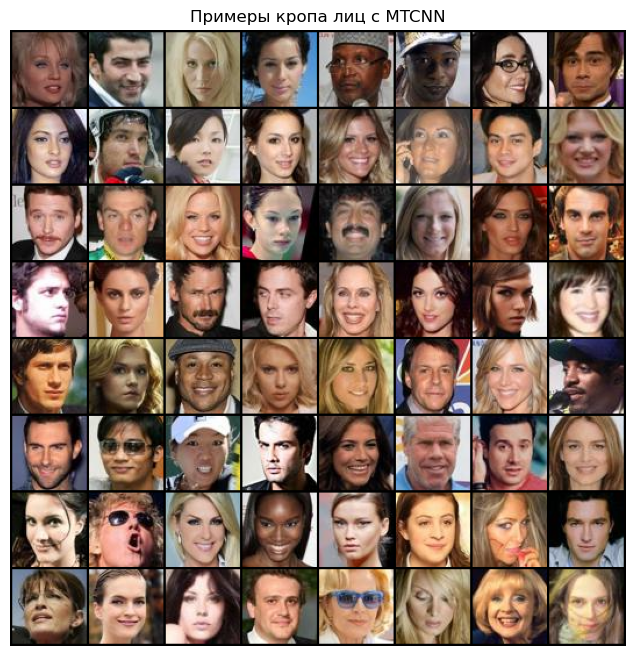

In [10]:
def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

def show(images, nrow=8, title=''):
    grid = make_grid(denorm(images).cpu(), nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.title(title)
    plt.show()

xb, yb = next(iter(train_loader))
show(xb[:64], title='Примеры кропа лиц с MTCNN')

In [11]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, latent_dim=128, ngf=64, conditional=False, num_classes=2, emb_dim=32):
        super().__init__()
        self.conditional = conditional
        if conditional:
            self.emb = nn.Embedding(num_classes, emb_dim)
            in_dim = latent_dim + emb_dim
        else:
            in_dim = latent_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels=None):
        if z.dim() == 2:
            z = z.unsqueeze(-1).unsqueeze(-1)
        if self.conditional:
            e = self.emb(labels).unsqueeze(-1).unsqueeze(-1)
            z = torch.cat([z, e], dim=1)
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64, conditional=False, num_classes=2):
        super().__init__()
        self.conditional = conditional
        if conditional:
            self.emb = nn.Embedding(num_classes, 1)
            in_ch = 4
        else:
            in_ch = 3

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x, labels=None):
        if self.conditional:
            b, _, h, w = x.shape
            lab = self.emb(labels).view(b, 1, 1, 1).expand(b, 1, h, w)
            x = torch.cat([x, lab], dim=1)
        return self.net(x).view(-1)

In [15]:
@torch.no_grad()
def compute_fid_is(G, loader, latent_dim, conditional=False, device=device, max_batches=None):
    G.eval()
    
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    is_metric = InceptionScore(normalize=True).to(device)

    for i, (real, labels) in enumerate(tqdm(loader, desc="FID/IS")):
        if max_batches is not None and i >= max_batches:
            break

        real = denorm(real).to(device)
        labels = labels.to(device)

        fid.update(real, real=True)

        z = torch.randn(real.size(0), latent_dim, device=device)
        if conditional:
            fake = G(z, labels)
        else:
            fake = G(z)

        fake = denorm(fake).to(device)
        fid.update(fake, real=False)
        is_metric.update(fake)

    fid_score = fid.compute().item()
    is_mean, is_std = is_metric.compute()
    return fid_score, is_mean.item(), is_std.item()

In [16]:
def train_gan(G, D, train_loader, val_loader, epochs=10, latent_dim=128, conditional=False, device=device):
    G = G.to(device)
    D = D.to(device)
    
    G.apply(weights_init)
    D.apply(weights_init)

    optG = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
    optD = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)
    criterion = nn.BCEWithLogitsLoss()

    history = {
        'g_loss': [],
        'd_loss': [],
        'fid': [],
        'is_mean': [],
        'is_std': []
    }

    for ep in range(epochs):
        G.train()
        D.train()

        g_loss_sum = 0.0
        d_loss_sum = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {ep+1}/{epochs}')
        for real, labels in pbar:
            real = real.to(device)
            labels = labels.to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, device=device)
            fake_targets = torch.zeros(bs, device=device)


            optD.zero_grad(set_to_none=True)

            out_real = D(real, labels if conditional else None)
            loss_real = criterion(out_real, real_targets)

            z = torch.randn(bs, latent_dim, device=device)
            fake = G(z, labels if conditional else None).detach()
            out_fake = D(fake, labels if conditional else None)
            loss_fake = criterion(out_fake, fake_targets)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            optD.step()

            
            optG.zero_grad(set_to_none=True)

            z = torch.randn(bs, latent_dim, device=device)
            gen = G(z, labels if conditional else None)
            out_gen = D(gen, labels if conditional else None)
            g_loss = criterion(out_gen, torch.ones(bs, device=device))

            g_loss.backward()
            optG.step()

            g_loss_sum += g_loss.item()
            d_loss_sum += d_loss.item()

            pbar.set_postfix({
                'G_loss': f'{g_loss.item():.3f}',
                'D_loss': f'{d_loss.item():.3f}'
            })

        g_loss_epoch = g_loss_sum / len(train_loader)
        d_loss_epoch = d_loss_sum / len(train_loader)

        fid, is_mean, is_std = compute_fid_is(
            G, val_loader, latent_dim,
            conditional=conditional,
            device=device
        )

        history['g_loss'].append(g_loss_epoch)
        history['d_loss'].append(d_loss_epoch)
        history['fid'].append(fid)
        history['is_mean'].append(is_mean)
        history['is_std'].append(is_std)

        print(
            f'Epoch {ep+1}: '
            f'G={g_loss_epoch:.4f}, D={d_loss_epoch:.4f}, '
            f'FID={fid:.2f}, IS={is_mean:.2f}+-{is_std:.2f}'
        )

    return G, D, history

In [18]:
G_u = Generator(latent_dim=128, conditional=False)
D_u = Discriminator(conditional=False)

G_u, D_u, hist_u = train_gan(
    G_u, D_u,
    train_loader, val_loader,
    epochs=10,
    latent_dim=128,
    conditional=False,
    device=device
)

FID/IS: 100%|██████████| 310/310 [04:08<00:00,  1.25it/s]


Epoch 1: G=5.7034, D=0.5559, FID=113.94, IS=1.95+-0.03


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 2: G=4.4408, D=0.5033, FID=57.86, IS=1.93+-0.02


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


...

Epoch 8: G=3.9871, D=0.3867, FID=34.77, IS=2.15+-0.03


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 9: G=4.0751, D=0.3496, FID=31.20, IS=2.09+-0.03


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 10: G=4.0823, D=0.3627, FID=28.03, IS=2.16+-0.03


In [19]:
def plot_history(hist, title=''):
    epochs = np.arange(1, len(hist['g_loss']) + 1)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, hist['g_loss'], label='G loss')
    plt.plot(epochs, hist['d_loss'], label='D loss')
    plt.xlabel('Epoch')
    plt.title(f'{title} losses')
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, hist['fid'], color='purple')
    plt.xlabel('Epoch')
    plt.title(f'{title} FID')
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, hist['is_mean'], color='green')
    plt.xlabel('Epoch')
    plt.title(f'{title} Inception Score')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

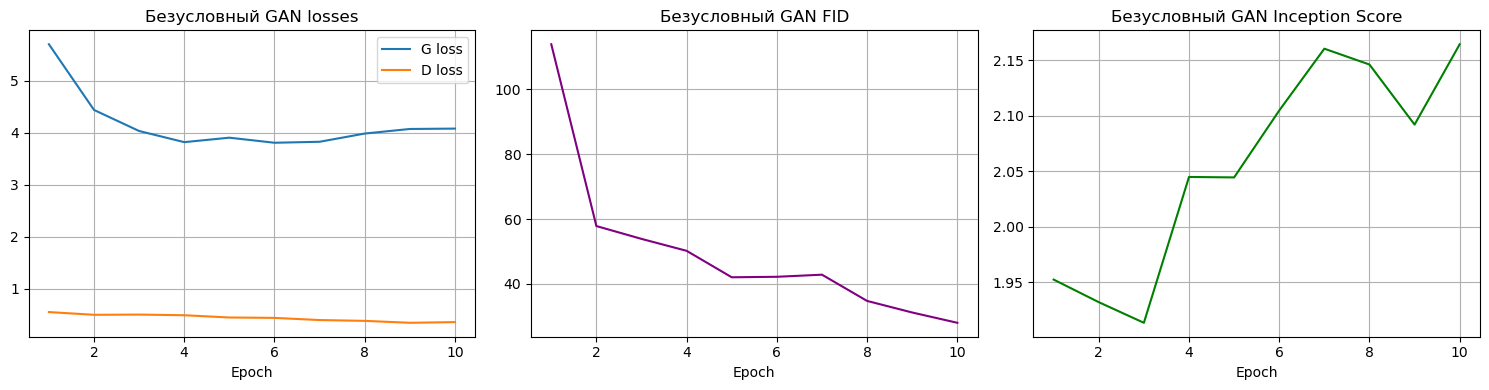

Метрики безусловного GAN:
FID: 28.03
IS: 2.16 +- 0.03


In [21]:
plot_history(hist_u, title='Безусловный GAN')

print('Метрики безусловного GAN:')
print(f"FID: {hist_u['fid'][-1]:.2f}")
print(f"IS: {hist_u['is_mean'][-1]:.2f} +- {hist_u['is_std'][-1]:.2f}")

In [23]:
G_c = Generator(latent_dim=128, conditional=True)
D_c = Discriminator(conditional=True)

G_c, D_c, hist_c = train_gan(
    G_c, D_c,
    train_loader, val_loader,
    epochs=10,
    latent_dim=128,
    conditional=True,
    device=device
)

FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 1: G=5.2288, D=0.6654, FID=194.17, IS=2.29+-0.04


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 2: G=4.9928, D=0.4688, FID=111.04, IS=1.89+-0.02


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


...

Epoch 8: G=4.9398, D=0.2871, FID=58.38, IS=1.96+-0.03


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 9: G=4.8506, D=0.2747, FID=60.19, IS=2.06+-0.02


FID/IS: 100%|██████████| 310/310 [02:37<00:00,  1.97it/s]


Epoch 10: G=4.8971, D=0.2493, FID=55.91, IS=2.07+-0.03


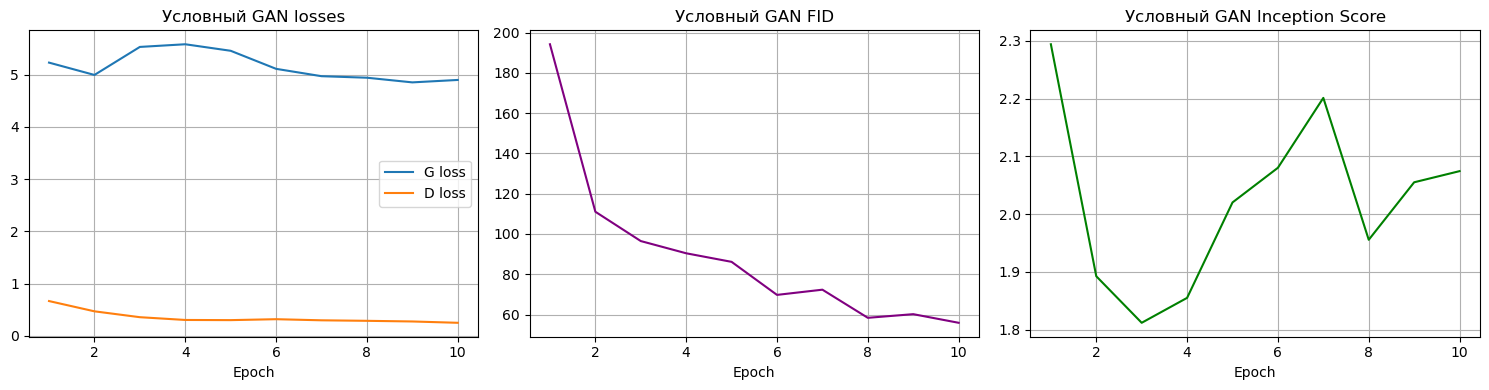

Метрики условного GAN:
FID: 55.91
IS: 2.07 +- 0.03


In [24]:
plot_history(hist_c, title='Условный GAN')

print('Метрики условного GAN:')
print(f"FID: {hist_c['fid'][-1]:.2f}")
print(f"IS: {hist_c['is_mean'][-1]:.2f} +- {hist_c['is_std'][-1]:.2f}")

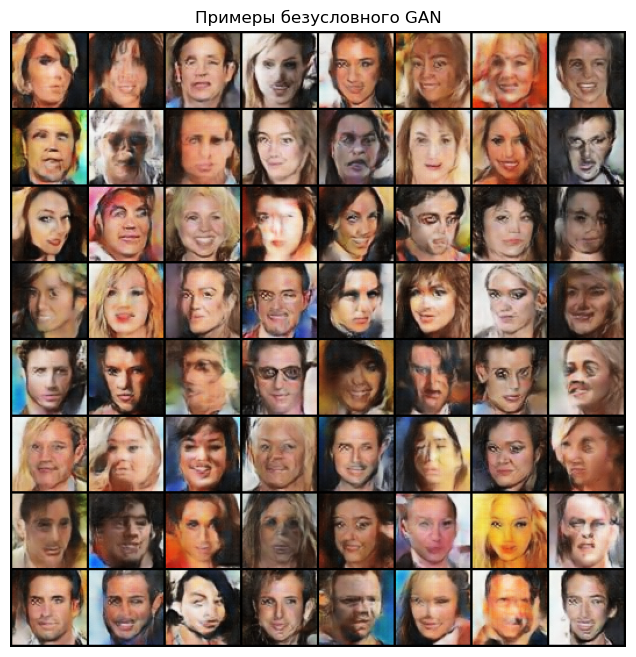

In [25]:
z = torch.randn(64, 128, device=device)
with torch.no_grad():
    fake_u = G_u(z)
show(fake_u, title='Примеры безусловного GAN')

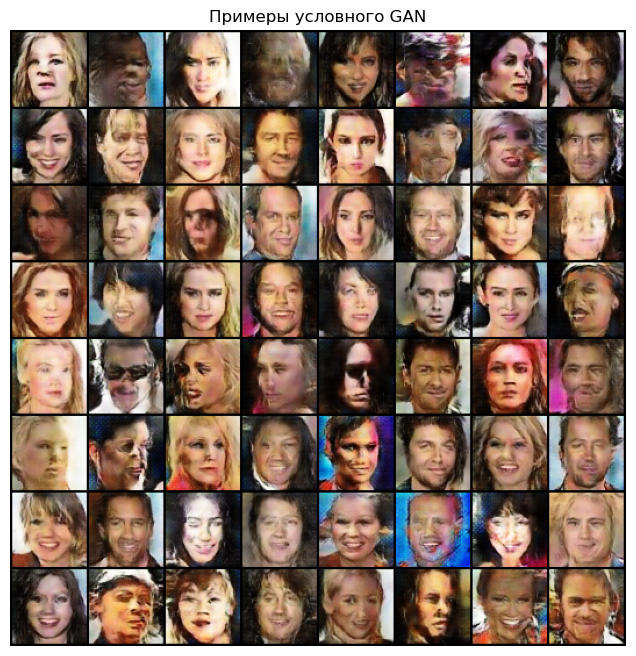

In [26]:
z = torch.randn(64, 128, device=device)
labels = torch.tensor([0, 1] * 32, dtype=torch.long, device=device)

with torch.no_grad():
    fake_c = G_c(z, labels)
show(fake_c, title='Примеры условного GAN')

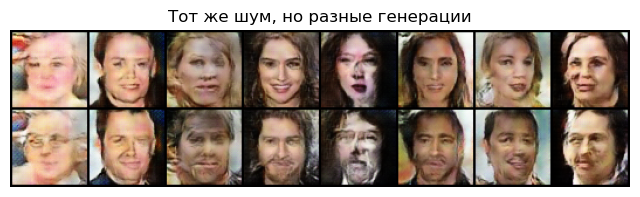

In [29]:
n = 8
same_z = torch.randn(n, 128, device=device)

labels_female = torch.zeros(n, dtype=torch.long, device=device)
labels_male = torch.ones(n, dtype=torch.long, device=device)

with torch.no_grad():
    imgs_f = G_c(same_z, labels_female).cpu()
    imgs_m = G_c(same_z, labels_male).cpu()

combined = torch.cat([imgs_f, imgs_m], dim=0)
show(combined, nrow=n, title='Тот же шум, но разные генерации')